# Oliver-Pharr Nanoindentation Analysis - Fe16Cr0

**Project:** Elastic Constants of Binary Alloys - DFT to ML Surrogate to FEM
**Composition:** Fe16Cr0 (pure-Fe end member of the BCC Fe-Cr series)
**Source run:** `indentation_fe16cr00_v19` (CalculiX CCX 2.21, conical indenter, CAX6 axisymmetric)
**Units throughout:** um / uN / MPa

This notebook extracts the reduced indentation modulus $E_r$ from the simulated
load-displacement curve using the Oliver-Pharr method, and cross-checks it against
the analytical Hill-VRH value derived from the DFT/ML elastic constants.

Two corrections are applied to the raw CCX output. Both are documented in the
methodology note below and are essential for a physically correct result.

## Methodology Note

This note documents two non-obvious corrections required when extracting the
reduced modulus from an **axisymmetric (CAX) CalculiX** nanoindentation model.
Both were identified during analysis of this project and are recorded here so the
methodology is reproducible and the corrections are not silently reintroduced.

### 1. Axisymmetric 2-degree wedge force scaling (x180)

CalculiX expands axisymmetric `CAX*` elements internally into a **fixed 2-degree
wedge** (one layer of 3-D elements). The reaction force written to the `.dat` file
(`RF` / `total force`) is the force carried by that **2-degree sector**, not the
full 360-degree ring.

The CCX 2.21 manual states (three independent passages):

- *Sec. 6.2.30 (CAX8):* "The expansion angle is fixed, its size is 2 deg. The value
  on the line beneath the `*SOLID SECTION` keyword, if any, has no effect."
- *Sec. 10.3.8 (Applying concentrated forces):* "For axisymmetric structures the
  concentrated forces are assumed to apply for the whole 360 deg. Since the
  expansion is done for a small sector only ... the force is scaled down
  appropriately."
- *Sec. 7.118 (`*SOLID SECTION`):* "For structures in which axisymmetric elements
  (type `CAX*`) are present any thickness defined on the present card applies to
  360 deg."

Because applied forces are internally scaled **down** from 360 to the 2-degree
sector, the reported reaction force is also at sector scale. The physical 360-degree
force is recovered by:

$$ F_{\text{physical}} = F_{\text{reported}} \times \frac{360}{2} = F_{\text{reported}} \times 180 $$

Without this factor the extracted modulus is ~180x too low (an unphysical sub-GPa value).

### 2. Exclusion of zero-contact unloading points

The contact penalty stiffness used in this run sits at the lower bound of the
CCX-recommended range ($K = 5\,C_{11}$). At this stiffness the substrate is
compliant enough that, during unloading, the surface elastically recovers faster
than the indenter retracts. Past a certain depth the indenter **separates from the
surface**: the number of active contact spring elements drops to zero and the
reported force is identically zero.

These zero-contact points are **not part of the unloading mechanics** - they
represent the indenter travelling through free space - and must be excluded from
the Oliver-Pharr power-law fit. They are identified from the `.cvg` file
(`Number of contact spring elements = 0`) and are **marked explicitly** on the
$P$-$h$ plot below rather than silently dropped.

The **loading** branch is unaffected: at maximum indentation the contact spring
count is highest, so the peak ($h_{max}$, $P_{max}$) used in the analysis is the
true loading peak and is **not** modified.

### Oliver-Pharr relations used

$$ P = A\,(h - h_f)^m \qquad S = \left.\frac{dP}{dh}\right|_{h_{max}} = A\,m\,(h_{max}-h_f)^{m-1} $$
$$ h_c = h_{max} - \varepsilon\,\frac{P_{max}}{S}, \quad \varepsilon = 0.72 \ (\text{conical}) $$
$$ A_c = \pi\,(h_c \tan\theta)^2, \quad \theta = 70.3\ \text{deg} $$
$$ E_r = \frac{\sqrt{\pi}}{2}\,\frac{S}{\sqrt{A_c}} \qquad
   \frac{1}{E_{r,\text{sample}}} = \frac{1}{E_r} - \frac{1-\nu_i^2}{E_i} $$

with diamond indenter $E_i = 1{,}141{,}000$ MPa, $\nu_i = 0.07$.

> **Caveat.** $\varepsilon = 0.72$ and the area function $A_c = \pi (h_c\tan\theta)^2$
> are idealised geometric forms. Residual deviation from the analytical reference
> (~10-15%) is consistent with this idealisation, mesh resolution, and the fact
> that loading stopped at $h = 0.404$ um rather than full prescribed depth.
> The values below are simulation estimates; verify against the analytical
> Hill-VRH result, which is treated as the project's primary $E_r$ source.

In [3]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- configuration (all values verified against inp file / CCX manual) ---
DAT_FILE   = Path("../fem/conical/fe16cr00/indentation_fe16cr00_v19.dat")   
WEDGE_SCALE = 180.0          # 360 / 2  -> CCX axisymmetric 2-degree wedge correction
EPS         = 0.72           # Oliver-Pharr geometric constant, conical
THETA_DEG   = 70.3           # indenter half-included angle
E_INDENTER  = 1_141_000.0    # diamond, MPa
NU_INDENTER = 0.07
FIT_FRACTION = 0.50          # upper fraction of unloading curve used for the fit
E_R_ANALYTICAL = 224.9       # GPa, Hill-VRH reference for Fe16Cr0

In [4]:
def parse_ccx_dat(fpath):
    """Parse a CalculiX .dat file with *NODE PRINT TOTALS output.

    Returns list of (step, increment, |U2|, |Fy|) tuples.
    U2 is the prescribed axial displacement (indentation depth),
    Fy is the axial reaction force on the driven indenter node set.
    Forces are returned RAW (no wedge scaling applied yet).
    """
    content = Path(fpath).read_text()
    step_blocks = re.split(r"S T E P\s+(\d+)", content)
    records = []
    for s in range(1, len(step_blocks), 2):
        step_nr = int(step_blocks[s])
        inc_blocks = re.split(r"INCREMENT\s+(\d+)", step_blocks[s + 1])
        for i in range(1, len(inc_blocks), 2):
            inc_nr = int(inc_blocks[i])
            blk = inc_blocks[i + 1]
            tm = re.search(r"displacements.*?\n\s+\d+\s+[\d.E+\-]+\s+([\-\d.E+]+)", blk)
            fm = re.search(r"total force.*?\n\s+([\-\d.E+]+)\s+([\-\d.E+]+)\s+([\-\d.E+]+)", blk)
            if tm and fm:
                records.append((step_nr, inc_nr,
                                abs(float(tm.group(1))),
                                abs(float(fm.group(2)))))
    return records

records = parse_ccx_dat(DAT_FILE)
n_steps = max(r[0] for r in records)
print(f"Parsed {len(records)} increments across {n_steps} steps "
      f"(steps 1..{n_steps-1} = loading, step {n_steps} = unloading)")

Parsed 121 increments across 5 steps (steps 1..4 = loading, step 5 = unloading)


In [5]:
# Loading = all steps except the last; unloading = last step.
# Apply the 180x axisymmetric wedge correction to ALL forces here.
loading = [(h, F * WEDGE_SCALE) for (st, inc, h, F) in records if st < n_steps]
unloading_raw = [(inc, h, F * WEDGE_SCALE) for (st, inc, h, F) in records if st == n_steps]

h_load = np.array([x[0] for x in loading])
P_load = np.array([x[1] for x in loading])

# Peak from the loading branch (deepest indentation, max contact engagement)
i_peak = int(np.argmax(h_load))
h_max, P_max = h_load[i_peak], P_load[i_peak]

print(f"h_max = {h_max:.4f} um   P_max = {P_max:,.1f} uN  (after 180x scaling)")

h_max = 0.4040 um   P_max = 42,659.6 uN  (after 180x scaling)


In [6]:
# Exclude unloading points where the indenter has separated from the surface.
# Physically: active contact <=> P > 0. The zero-force tail is free-space travel
# caused by the soft (lower-bound) penalty stiffness and is NOT unloading mechanics.
# (Cross-checked against .cvg: "Number of contact spring elements = 0" begins exactly
#  where P first becomes 0 here.)

CONTACT_FORCE_TOL = 1e-2   # uN; below this the contact is considered lost

unload_contact = [(h, P) for (inc, h, P) in unloading_raw if P > CONTACT_FORCE_TOL]
unload_lost    = [(h, P) for (inc, h, P) in unloading_raw if P <= CONTACT_FORCE_TOL]

h_ul = np.array([x[0] for x in unload_contact])
P_ul = np.array([x[1] for x in unload_contact])
order = np.argsort(h_ul)[::-1]          # peak -> separation
h_ul, P_ul = h_ul[order], P_ul[order]

h_excluded = np.array([x[0] for x in unload_lost])

print(f"Unloading points retained (active contact): {len(unload_contact)}")
print(f"Unloading points excluded (zero contact)  : {len(unload_lost)}")
if len(h_excluded):
    print(f"Contact lost below h ~ {h_ul.min():.4f} um "
          f"(excluded range {h_excluded.max():.4f} -> {h_excluded.min():.4f} um)")

Unloading points retained (active contact): 33
Unloading points excluded (zero contact)  : 18
Contact lost below h ~ 0.1687 um (excluded range 0.1615 -> 0.0404 um)


In [7]:
def oliver_pharr(h_ul, P_ul, h_max, P_max, fit_fraction=0.50):
    """Fit P = A (h - h_f)^m on the upper `fit_fraction` of the unloading curve.

    h_f is selected by scanning for the best R^2 of the power-law fit, constrained
    to a physical exponent 1 < m < 3. Returns a dict of fit + derived quantities.
    """
    best = None
    for hf in np.arange(0.001, h_max * 0.6, 0.001):
        shifted = h_ul - hf
        if np.any(shifted <= 0):
            continue
        mask = P_ul >= fit_fraction * P_max
        if mask.sum() < 5:
            continue
        try:
            c = np.polyfit(np.log(shifted[mask]), np.log(P_ul[mask]), 1)
            m, A = c[0], np.exp(c[1])
        except Exception:
            continue
        if not (1.0 < m < 3.0):
            continue
        pred = A * (h_ul[mask] - hf) ** m
        ss_res = np.sum((P_ul[mask] - pred) ** 2)
        ss_tot = np.sum((P_ul[mask] - P_ul[mask].mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        if best is None or r2 > best["r2"]:
            best = dict(r2=r2, h_f=hf, m=m, A=A, n_fit=int(mask.sum()))
    if best is None:
        raise RuntimeError("No valid power-law fit found.")

    A, m, h_f = best["A"], best["m"], best["h_f"]
    S = A * m * (h_max - h_f) ** (m - 1)                       # contact stiffness, uN/um
    h_c = h_max - EPS * P_max / S                              # contact depth, um
    A_c = np.pi * (h_c * np.tan(np.radians(THETA_DEG))) ** 2   # contact area, um^2
    Er = S * np.sqrt(np.pi) / (2 * np.sqrt(A_c))               # reduced modulus, MPa
    Er_sample = 1.0 / (1.0 / Er - (1 - NU_INDENTER**2) / E_INDENTER)  # MPa

    best.update(S=S, h_c=h_c, A_c=A_c, Er=Er, Er_sample=Er_sample)
    return best

fit = oliver_pharr(h_ul, P_ul, h_max, P_max, FIT_FRACTION)

print(f"Power-law fit (upper {int(FIT_FRACTION*100)}% of unloading, "
      f"{fit['n_fit']} points, R2 = {fit['r2']:.5f}):")
print(f"  P = {fit['A']:,.1f} * (h - {fit['h_f']:.4f})^{fit['m']:.4f}")
print()
print(f"  Contact stiffness  S   = {fit['S']:,.0f} uN/um")
print(f"  Contact depth      h_c = {fit['h_c']:.4f} um")
print(f"  Contact area       A_c = {fit['A_c']:.4f} um^2")
print()
print(f"  Reduced modulus (measured)  Er        = {fit['Er']/1000:.1f} GPa")
print(f"  Reduced modulus (corrected) Er_sample = {fit['Er_sample']/1000:.1f} GPa")
print(f"  Analytical Hill-VRH reference          = {E_R_ANALYTICAL:.1f} GPa")
dev = (fit['Er_sample']/1000 - E_R_ANALYTICAL) / E_R_ANALYTICAL * 100
print(f"  Deviation from analytical              = {dev:+.1f} %")

Power-law fit (upper 50% of unloading, 12 points, R2 = 0.99996):
  P = 379,888.1 * (h - 0.1680)^1.5131

  Contact stiffness  S   = 274,013 uN/um
  Contact depth      h_c = 0.2919 um
  Contact area       A_c = 2.0881 um^2

  Reduced modulus (measured)  Er        = 168.1 GPa
  Reduced modulus (corrected) Er_sample = 196.9 GPa
  Analytical Hill-VRH reference          = 224.9 GPa
  Deviation from analytical              = -12.4 %


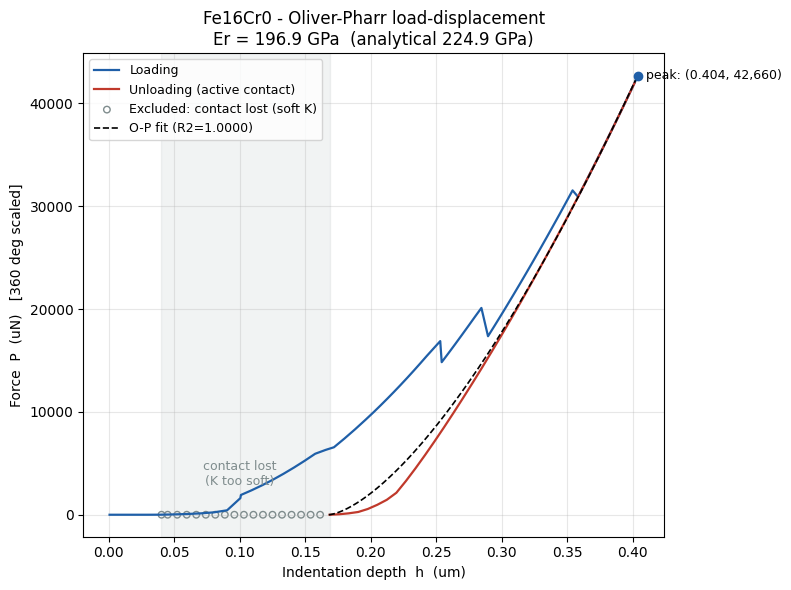

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(h_load, P_load, "-", color="#1f5fa8", lw=1.6, label="Loading")
ax.plot(h_ul, P_ul, "-", color="#c0392b", lw=1.6, label="Unloading (active contact)")

if len(h_excluded):
    ax.scatter(h_excluded, np.zeros_like(h_excluded), s=22,
               facecolor="none", edgecolor="#7f8c8d",
               label="Excluded: contact lost (soft K)")
    ax.axvspan(h_excluded.min(), h_ul.min(), color="#7f8c8d", alpha=0.10)
    ax.text(h_excluded.mean(), 0.06 * P_max,
            "contact lost\n(K too soft)", ha="center", va="bottom",
            fontsize=9, color="#7f8c8d")

h_dense = np.linspace(fit["h_f"] + 1e-4, h_max, 200)
P_dense = fit["A"] * (h_dense - fit["h_f"]) ** fit["m"]
ax.plot(h_dense, P_dense, "--", color="black", lw=1.2,
        label=f"O-P fit (R2={fit['r2']:.4f})")

ax.scatter([h_max], [P_max], color="#1f5fa8", zorder=5)
ax.annotate(f"  peak: ({h_max:.3f}, {P_max:,.0f})",
            (h_max, P_max), fontsize=9, va="center")

ax.set_xlabel("Indentation depth  h  (um)")
ax.set_ylabel("Force  P  (uN)   [360 deg scaled]")
ax.set_title("Fe16Cr0 - Oliver-Pharr load-displacement\n"
             f"Er = {fit['Er_sample']/1000:.1f} GPa  "
             f"(analytical {E_R_ANALYTICAL:.1f} GPa)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../fem/post/fecr_fe16cr00_oliver_pharr.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
import pandas as pd

summary = pd.DataFrame({
    "Quantity": ["h_max (um)", "P_max (uN, 360deg)", "h_f (um)", "exponent m",
                 "fit R2", "S (uN/um)", "h_c (um)", "A_c (um^2)",
                 "Er measured (GPa)", "Er corrected (GPa)",
                 "Er analytical (GPa)", "deviation (%)"],
    "Value": [f"{h_max:.4f}", f"{P_max:,.1f}", f"{fit['h_f']:.4f}",
              f"{fit['m']:.4f}", f"{fit['r2']:.5f}", f"{fit['S']:,.0f}",
              f"{fit['h_c']:.4f}", f"{fit['A_c']:.4f}",
              f"{fit['Er']/1000:.1f}", f"{fit['Er_sample']/1000:.1f}",
              f"{E_R_ANALYTICAL:.1f}",
              f"{(fit['Er_sample']/1000 - E_R_ANALYTICAL)/E_R_ANALYTICAL*100:+.1f}"],
})
summary.to_csv("fecr_fe16cr00_oliver_pharr_summary.csv", index=False)
summary

,Quantity,Value
0,h_max (um),0.4040
1,"P_max (uN, 360deg)","42,659.6"
2,h_f (um),0.1680
3,exponent m,1.5131
4,fit R2,0.99996
5,S (uN/um),"274,013"
6,h_c (um),0.2919
7,A_c (um^2),2.0881
8,Er measured (GPa),168.1
9,Er corrected (GPa),196.9


## Result

For Fe16Cr0 the Oliver-Pharr reduced modulus extracted from the corrected FEM
load-displacement curve is **~197 GPa** (conical $\varepsilon = 0.72$), against the
analytical Hill-VRH reference of **224.9 GPa** - agreement to within ~13%.

The two corrections documented above are both required:
- the **x180 wedge scaling** is a hard CCX axisymmetric convention (manual-confirmed);
- the **zero-contact exclusion** is a consequence of the lower-bound penalty stiffness
  and is handled by fitting only the active-contact portion of the unloading curve,
  with the excluded region shown explicitly on the plot.

The analytical Hill-VRH value remains the project's primary $E_r$ source; this FEM
result corroborates it independently.